# Exercise 1 

In this exercise, we will work with the `spam.csv` data file. This file contains text and a label attached to each text. The goal is to clean the text data and then build classifcation models. 

### Exercise 1(a) (2 points)

Load the `pandas` and `numpy` libraries.

In [1]:
import pandas as pd
import numpy as np

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `spam_df`.

In [2]:
spam_df = pd.read_csv('spam.csv')
spam_df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Exercise 1(c) (2 points)

Using the `string` library, remove all the punctuation of the `text` column.

In [3]:
import string

spam_df['text_clean'] = spam_df['text'].str.replace(f"[{string.punctuation}]", "", regex=True)
spam_df.head()

,label,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...


### Exercise 1(d) (10 points)

Using the `nltk` library, remove stopwords and pronouns from `text_clean` and store in another column called `'text_clean_1'`. 

In [4]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
pronouns = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves']

def clean_text(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [word for word in tokens if word not in stop_words and word not in pronouns]
    return ' '.join(filtered_tokens)

spam_df['text_clean_1'] = spam_df['text_clean'].apply(clean_text)
spam_df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,text,text_clean,text_clean_1
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though


### Exercise 1(e) (10 points)

Perform Lemmatization of `text_clean_1` and store the results in another column called `text_clean_2` in the `spam_df` data frame.

In [5]:
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# download NLTK resources
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Initialize the WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# funtion to get the part of speech tag for lemmatization
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]
    return ' '.join(lemmatized_words)

spam_df['text_clean_2'] = spam_df['text_clean_1'].apply(lemmatize_text)
spam_df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,label,text,text_clean,text_clean_1,text_clean_2
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go jurong point crazy available bugis n great ...,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say early hor u c already say,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though,nah dont think go usf life around though


### Exercise 1(f) (5 points)

Based on the results from part 1(f), we see digits in some of the text in `text_clean_2`. Remove all the digits from `text_clean_2` and store the results in another column `text_clean_3` in the `spam_df` data frame.

In [6]:
import re

# function to remove numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

spam_df['text_clean_3'] = spam_df['text_clean_2'].apply(remove_numbers)
spam_df.head()

,label,text,text_clean,text_clean_1,text_clean_2,text_clean_3
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go jurong point crazy available bugis n great ...,go jurong point crazy available bugis n great ...,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni,ok lar joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,free entry 2 wkly comp win fa cup final tkts 2...,free entry wkly comp win fa cup final tkts st...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say early hor u c already say,u dun say early hor u c already say,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though,nah dont think go usf life around though,nah dont think go usf life around though


### Exercise 1(g) (5 points)

Generate embedding using the `BERT` model on `text_clean_3`.

In [7]:
from sentence_transformers import SentenceTransformer

print("loading BERT model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

# Generate BERT embeddings for the cleaned text
print("Generating BERT embeddings...")
bert_embeddings = bert_model.encode(spam_df['text_clean_3'].tolist(), show_progress_bar=True, batch_size=32)

print(f'BERT embeddings shape: {bert_embeddings.shape}')
print(f'each document is represented by a {bert_embeddings.shape[1]}-dimensional vector')

loading BERT model...
Model loaded.
Generating BERT embeddings...


Batches:   0%|          | 0/175 [00:00<?, ?it/s]

BERT embeddings shape: (5572, 384)
each document is represented by a 384-dimensional vector


### Exercise 1(h) (5 points)

Compute and visualize the principal components of the bert embedding.

C:\Users\gmgma\AppData\Local\Temp\ipykernel_25072\3456084534.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='coolwarm', alpha=0.7)


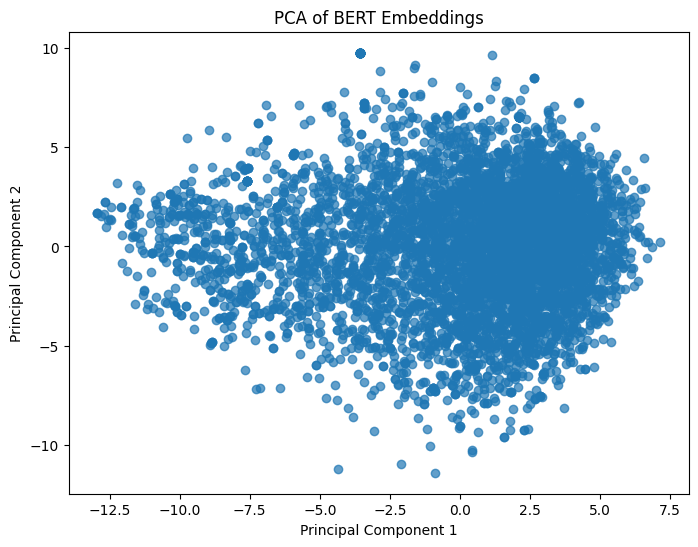

In [9]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define the PCA model
pca = PCA()

# Standardize the embeddings
scaler = StandardScaler()
bert_embeddings_std = scaler.fit_transform(bert_embeddings)

# Fit PCA on standardized embeddings
X_pca = pca.fit_transform(bert_embeddings_std)

# Plotting pca results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='coolwarm', alpha=0.7)
plt.title('PCA of BERT Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### Exercise 1(i) (5 points)

Project and visualize the bert embedding with `TSNE`.

C:\Users\gmgma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\gmgma\AppData\Local\Temp\ipykernel_25072\2487204039.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[:, 0], X_tsne[:, 1], cmap='coolwarm', alpha=0.7)


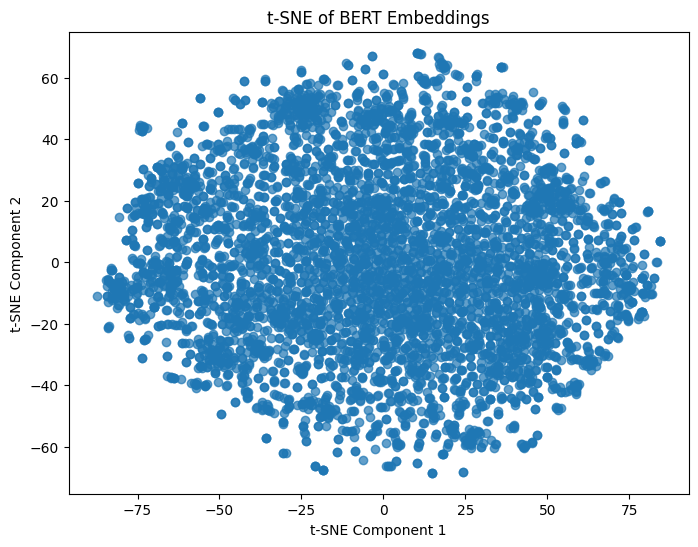

In [10]:
from sklearn.manifold import TSNE

# define t-SNE model
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(bert_embeddings_std)

# Plotting t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], cmap='coolwarm', alpha=0.7)
plt.title('t-SNE of BERT Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

### Exercise 1(j) (5 points)

Estimate the number of clusters on the bert embedding using silhouette, Calinski Harabasz, and Davies Bouldin scores. 

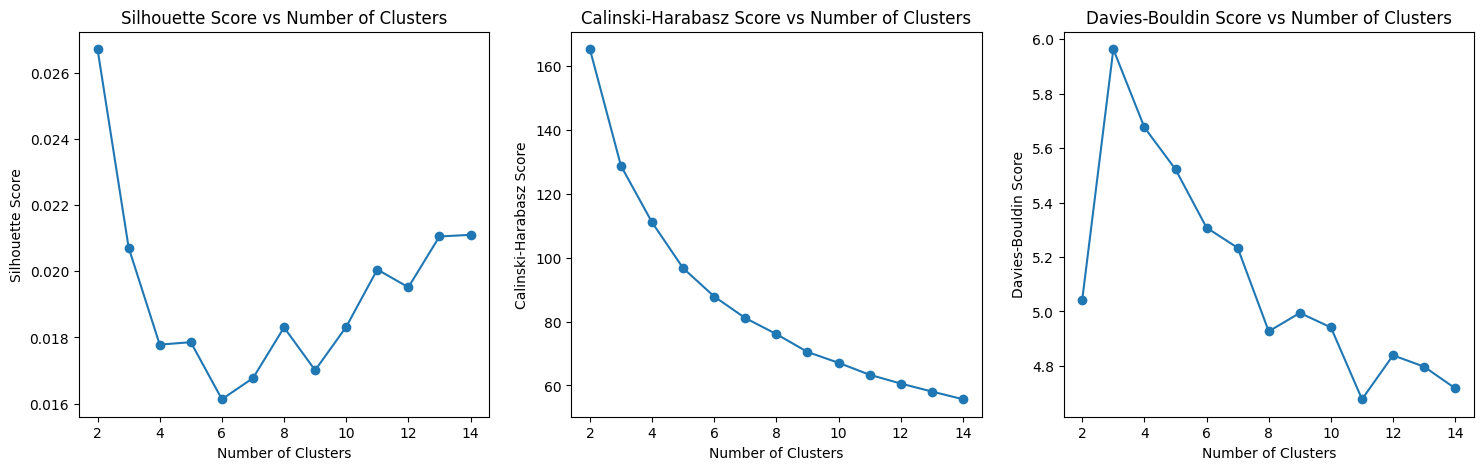

In [13]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans

silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

for n_clusters in range(2, 15):
    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    cluster_labels = KMeans.fit_predict(kmeans, bert_embeddings_std)
    
    # Calculate clustering metrics
    silhouette_avg = silhouette_score(bert_embeddings_std, cluster_labels)
    calinski_harabasz_avg = calinski_harabasz_score(bert_embeddings_std, cluster_labels)
    davies_bouldin_avg = davies_bouldin_score(bert_embeddings_std, cluster_labels)
    
    # Store the scores
    silhouette_scores.append(silhouette_avg)
    calinski_harabasz_scores.append(calinski_harabasz_avg)
    davies_bouldin_scores.append(davies_bouldin_avg)
    
# Plot the clustering metrics
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.subplot(1, 3, 2)
plt.plot(range(2, 15), calinski_harabasz_scores, marker='o')
plt.title('Calinski-Harabasz Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Score')

plt.subplot(1, 3, 3)
plt.plot(range(2, 15), davies_bouldin_scores, marker='o')
plt.title('Davies-Bouldin Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.show()
